# Solar GHI Forecasting — Statistical Models

This notebook builds and evaluates **ARIMA-family statistical models** for forecasting **Global Horizontal Irradiance (GHI)** using the engineered dataset from `solar_feature_engineering.ipynb`.

**Dataset:** 8,736 hourly observations · Jan–Dec 2022 · Spain (40.97°N, −4.54°W)  
**Target:** `GHI` — Global Horizontal Irradiance (W/m²)  
**Train/Test split:** 80% train (Jan–Oct 2022) / 20% test (Oct–Dec 2022), chronological

**Model progression — each step adds one structural component:**

| Model | What it knows |
|-------|--------------|
| `ARIMA(5,0,1)` | Past GHI values only |
| `SARIMA(2,0,2)(1,1,1,24)` | Past GHI + 24-hour diurnal seasonal pattern |
| `SARIMAX(2,0,1)(1,1,1,24)` | Past GHI + seasonality + 8 engineered physical features |

---

## 1. Setup & Data Loading

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('../../outputs/df_engineered.csv', 
                  index_col='datetime', 
                  parse_dates=True)

In [20]:
df.columns

Index(['Temperature', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI',
       'Cloud Type', 'Relative Humidity', 'Pressure', 'Wind Direction',
       'Wind Speed', 'DHI', 'DNI', 'GHI', 'Solar Zenith Angle',
       'Precipitable Water', 'Surface Albedo', 'Fill Flag', 'Dew Point',
       'Asymmetry', 'Aerosol Optical Depth', 'Alpha', 'solar_zenith',
       'solar_elevation', 'ET_irradiance', 'hour_sin', 'hour_cos', 'doy_sin',
       'doy_cos', 'month', 'week_of_year', 'day_of_week', 'GHI_lag_1h',
       'GHI_lag_3h', 'GHI_lag_24h', 'temp_lag_1h', 'temp_lag_3h',
       'temp_lag_24h', 'humidity_lag_1h', 'humidity_lag_3h',
       'humidity_lag_24h', 'GHI_rollmean_3h', 'GHI_rollmean_6h',
       'GHI_rollmean_24h', 'GHI_rollstd_3h', 'GHI_rollstd_6h',
       'GHI_rollstd_24h', 'cloud_cover_proxy', 'humidity_x_temp',
       'cloud_x_elevation'],
      dtype='object')

## 2. Feature–Target Correlations

Before modelling, we inspect how strongly each engineered feature correlates with GHI (Pearson r). This guides which features are worth passing to SARIMAX as exogenous regressors.

**28 engineered features across 5 categories:**

| Category | Features | Count |
|----------|---------|-------|
| Solar geometry | `solar_zenith`, `solar_elevation`, `ET_irradiance` | 3 |
| Cyclical time | `hour_sin/cos`, `doy_sin/cos`, `month`, `week_of_year`, `day_of_week` | 7 |
| GHI / Temp / Humidity lags | 1h, 3h, 24h backward shifts for each | 9 |
| Rolling statistics | GHI rolling mean and std at 3h, 6h, 24h windows | 6 |
| Interaction terms | `cloud_cover_proxy`, `cloud_x_elevation`, `humidity_x_temp` | 3 |

Features with **r > 0.7** are strong SARIMAX candidates. Features correlated with each other add redundancy — only the most informative from each correlated group is passed to the model.

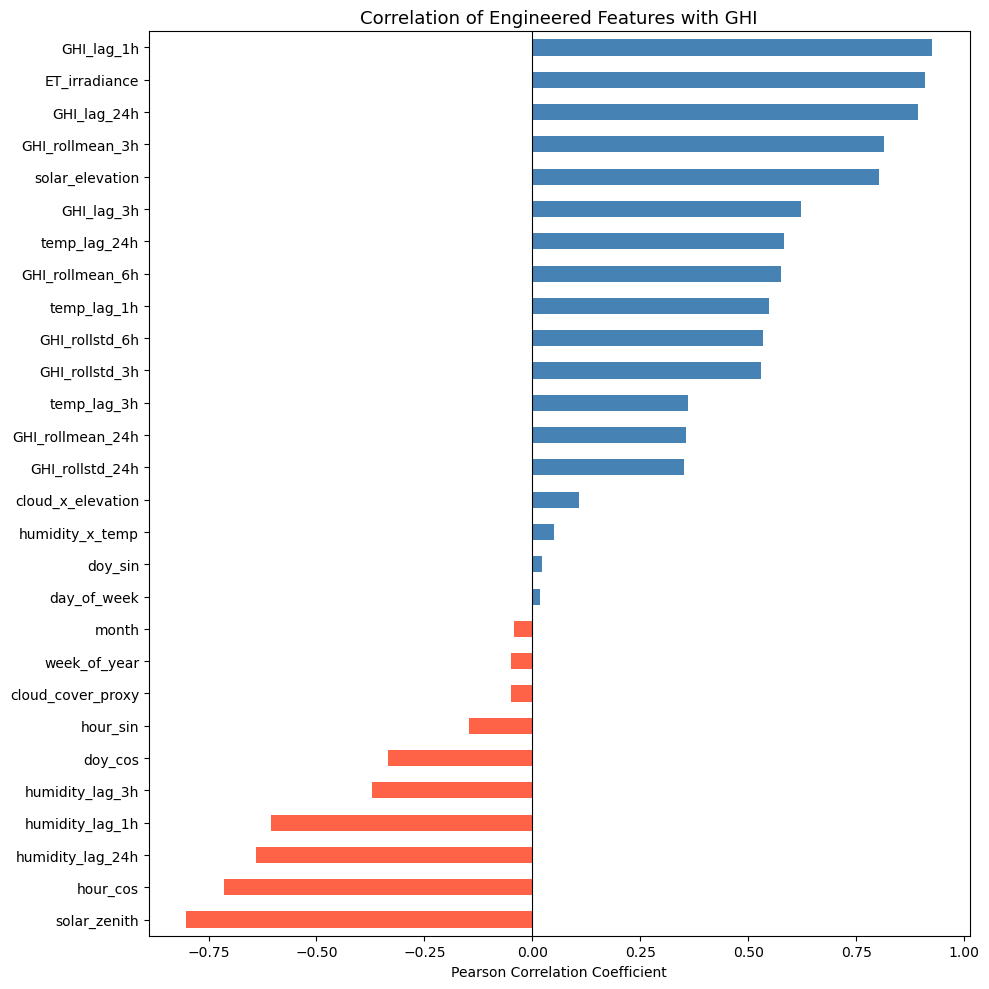

Top 5 positive correlations with GHI:
solar_elevation    0.802
GHI_rollmean_3h    0.814
GHI_lag_24h        0.893
ET_irradiance      0.910
GHI_lag_1h         0.926

Top 5 negative correlations with GHI:
solar_zenith       -0.802
hour_cos           -0.713
humidity_lag_24h   -0.639
humidity_lag_1h    -0.605
humidity_lag_3h    -0.372


In [21]:
# Correlation of each engineered feature with GHI only
cols_engineered = [
    # Task 1 - Solar geometry (3 features)
    'solar_zenith', 
    'solar_elevation', 
    'ET_irradiance',

    # Task 2 - Time features (7 features)
    'hour_sin', 
    'hour_cos', 
    'doy_sin', 
    'doy_cos', 
    'month',
    'week_of_year',
    'day_of_week',

    # Task 3 - Lag features (9 features)
    'GHI_lag_1h', 
    'GHI_lag_3h', 
    'GHI_lag_24h',
    'temp_lag_1h', 
    'temp_lag_3h', 
    'temp_lag_24h',
    'humidity_lag_1h', 
    'humidity_lag_3h', 
    'humidity_lag_24h',

    # Task 4 - Rolling stats (6 features)
    'GHI_rollmean_3h', 
    'GHI_rollmean_6h', 
    'GHI_rollmean_24h',
    'GHI_rollstd_3h',  
    'GHI_rollstd_6h',  
    'GHI_rollstd_24h',

    # Task 5 - Interactions (3 features)
    'cloud_cover_proxy', 
    'cloud_x_elevation', 
    'humidity_x_temp'
]
corr_with_ghi = df[cols_engineered + ['GHI']].corr()['GHI'].drop('GHI').sort_values()

plt.figure(figsize=(10, 10))
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_ghi.values]
corr_with_ghi.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlation of Engineered Features with GHI', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../../Outputs/correlation_with_ghi.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 positive correlations with GHI:')
print(corr_with_ghi.tail(5).round(3).to_string())
print('\nTop 5 negative correlations with GHI:')
print(corr_with_ghi.head(5).round(3).to_string())

In [22]:
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Missing values: {df.isnull().sum().sum()}')

Shape: (8736, 48)
Date range: 2022-01-02 00:30:00+01:00 to 2022-12-31 23:30:00+01:00
Missing values: 0


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred, y_train, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mse ** 0.5

    smape = (
        100
        * np.mean(
            2 * np.abs(y_pred - y_true)
            / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
        )
    )

    scale = np.mean(np.abs(np.diff(y_train)))
    mase = mae / scale if scale != 0 else np.nan

    return pd.DataFrame(
        {
            'Model': [model_name],
            'MSE': [mse],
            'MAE': [mae],
            'RMSE': [rmse],
            'sMAPE (%)': [smape],
            'MASE': [mase],
        }
    )

## 3. Evaluation Metrics Helper

A unified function to compute five error metrics for every model on the same test set, enabling direct comparison:

| Metric | Formula | Why it matters |
|--------|---------|----------------|
| **MSE** | mean((y − ŷ)²) | Penalises large errors heavily; sensitive to outliers |
| **MAE** | mean(\|y − ŷ\|) | Average absolute error in W/m²; easy to interpret |
| **RMSE** | √MSE | Same units as GHI — primary ranking metric |
| **sMAPE** | 200 × mean(\|y−ŷ\| / (\|y\|+\|ŷ\|)) | Scale-free percentage; symmetric around 0; handles zero GHI gracefully |
| **MASE** | MAE / mean(\|Δy_train\|) | Error relative to naïve random-walk; MASE < 1 means the model beats "predict same as last step" |

> **Note:** Nighttime GHI is always 0 W/m², so all models trivially predict 0 at night (enforced by `.clip(lower=0)`). The meaningful comparison is on daytime rows where actual GHI > 0.

In [24]:
import statsmodels
print(statsmodels.__version__)

0.14.5


## 4. Train / Test Split

**Strategy:** Chronological 80/20 split — no shuffling, no random state. Future data never leaks into the training window.

| Split | Period | Rows | Daytime (GHI > 0) | Nighttime (GHI = 0) |
|-------|--------|------|-------------------|---------------------|
| Train | Jan 2022 → Oct 2022 | 6,988 | — | — |
| Test | Oct 2022 → Dec 2022 | 1,748 | 697 (40%) | 1,051 (60%) |

The test window falls in autumn/winter, where solar elevation is lower and daytime is shorter — making it a harder evaluation period than summer months. The same `split` index is reused for all three models to ensure a fair comparison.

In [25]:
ghi = df['GHI']  

# Train/test split — 80% train, 20% test (chronological)
split = int(len(ghi) * 0.8)
train = ghi.iloc[:split]
test  = ghi.iloc[split:]

print(f'Train: {len(train)} rows  ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test:  {len(test)} rows   ({test.index.min().date()} to {test.index.max().date()})')
print(f'\nDaytime rows in test (GHI > 0): {(test > 0).sum()}')
print(f'Nighttime rows in test (GHI = 0): {(test == 0).sum()}')

Train: 6988 rows  (2022-01-02 to 2022-10-20)
Test:  1748 rows   (2022-10-20 to 2022-12-31)

Daytime rows in test (GHI > 0): 697
Nighttime rows in test (GHI = 0): 1051


## 5. Stationarity & Autocorrelation Analysis

Before fitting ARIMA-family models, two prerequisites must be checked:

**1. Stationarity (ADF test)**  
Result: ADF = −6.06, p-value ≈ 0.000 → series is stationary → **`d = 0`** (no differencing needed)

**2. Order selection from ACF / PACF plots**

| Plot | Tells us | Parameter |
|------|----------|-----------|
| PACF | Significant spikes up to lag `p`, then cuts off | AR order `p` |
| ACF | Gradual decay pattern; spike at lag `q` | MA order `q` |

**Key patterns to look for in solar GHI:**
- **ACF:** Large spike at lag 24 (strong diurnal cycle — same hour yesterday is highly correlated) and gradual decay within the day → confirms the need for a seasonal component at `s = 24`
- **PACF:** Significant spikes at lags 1–5, then cuts off → guides `p = 5` for ARIMA

> Seasonal differencing (`D = 1`) is applied in SARIMA and SARIMAX to remove the dominant 24-hour trend before fitting the seasonal AR/MA terms.

In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value:       {result[1]:.4f}')
print(f'Stationary:    {result[1] < 0.05}')

ADF Statistic: -6.0573
p-value:       0.0000
Stationary:    True


In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

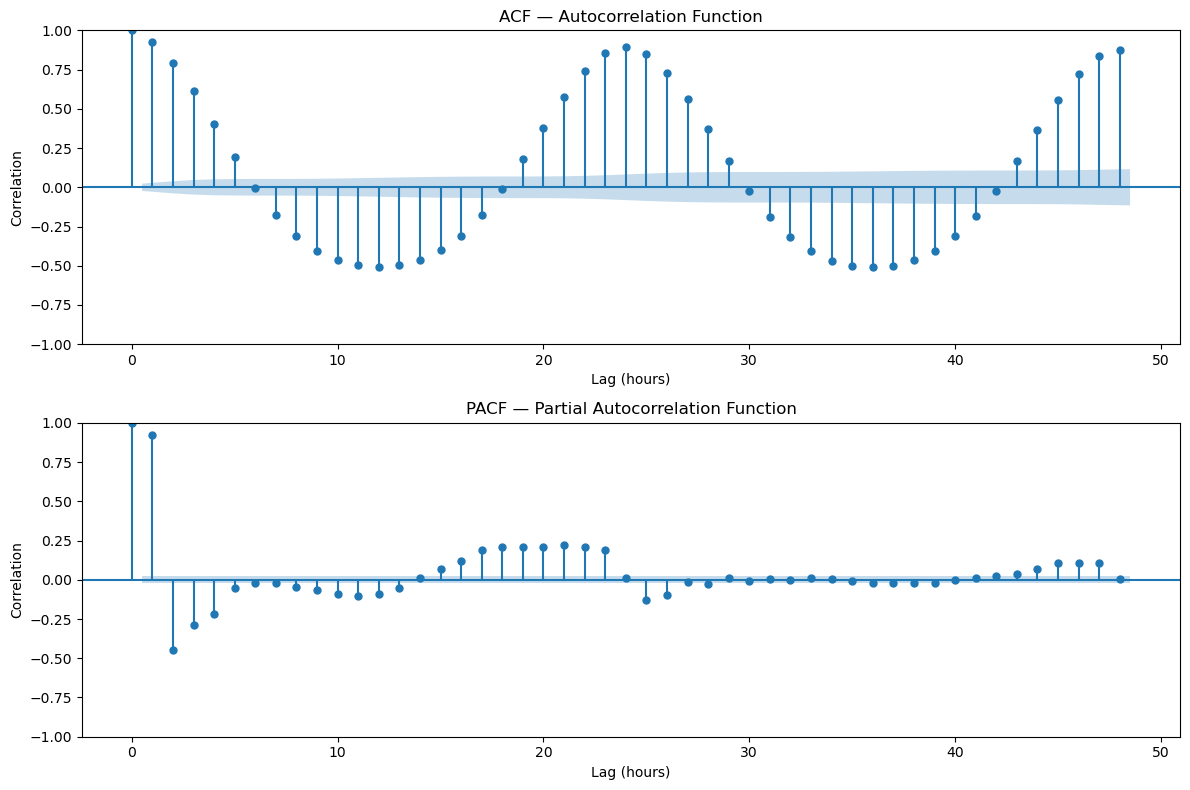

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train, lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — Autocorrelation Function')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Correlation')

plot_pacf(train, lags=48, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — Partial Autocorrelation Function')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.savefig('../../outputs/acf_pacf.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Statistical Baseline Models

Three ARIMA-family models in increasing complexity, each adding one structural component over the previous:

| Model | Order | What it adds |
|-------|-------|--------------|
| `ARIMA(5,0,1)` | p=5, d=0, q=1 | AR persistence only — no seasonality, no external features |
| `SARIMA(2,0,2)(1,1,1,24)` | s=24, D=1 | 24-hour seasonal structure via Kalman filter state |
| `SARIMAX(2,0,1)(1,1,1,24)` | 8 exog features | Physical and engineered features as external regressors |

**Evaluation strategy — why ARIMA and SARIMA use one-step-ahead:**

Multi-step `forecast()` over 1,748 steps converges to the series mean for models without exogenous input, producing a flat horizontal line. This is a known property of ARIMA models, not a bug. To get realistic predictions, `append(refit=False)` is used: it runs the Kalman filter forward through the test set, updating the model state with each actual observed GHI value before predicting the next step.

SARIMAX uses standard multi-step `forecast()` because its exogenous features (Clearsky GHI, hour encoding, lags) change at every future timestep and provide the signal needed to track the solar pattern without state updates.

In [29]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

### 6.1 ARIMA(5,0,1) — Non-seasonal Baseline

**Parameters chosen from ACF/PACF analysis:**
- `p = 5` — PACF shows significant spikes out to lag 5; five AR lags capture short-term solar persistence
- `d = 0` — ADF confirmed stationarity (p ≈ 0.000); no differencing needed
- `q = 1` — one MA term to absorb residual short-run shocks after AR lags are accounted for

**What this model can and cannot do:**
- ✓ Follows the recent trend (rising GHI → predicts more rising)
- ✓ Predicts near-zero at night after it has seen GHI drop
- ✗ Cannot anticipate sunrise — it sees zeros and predicts zeros until actual GHI rises
- ✗ Cannot distinguish a cloudy noon from a clear noon without seeing the GHI difference first

This is the weakest benchmark. Any model that cannot beat it lacks practical forecasting value.

In [ ]:
print('Fitting ARIMA(5,0,1)...')
model_arima = ARIMA(train, order=(5, 0, 1))
result_arima = model_arima.fit()

print(result_arima.summary().tables[0])

# One-step-ahead predictions via append(refit=False):
# runs Kalman filter over test set using actual observed values to update state at each step,
# avoiding the flat-line convergence problem of long multi-step forecasts
result_arima_oos = result_arima.append(test, refit=False)
forecast_arima = result_arima_oos.fittedvalues.iloc[split:].clip(lower=0)

results_arima = evaluate_forecast(test, forecast_arima, train, 'ARIMA(5,0,1)')
print(results_arima.to_string(index=False))

### 6.2 SARIMA(2,0,2)(1,1,1,24) — Adding 24-Hour Seasonality

Extends ARIMA by adding a **seasonal component at `s = 24`** that explicitly models the 24-hour diurnal solar cycle.

**Parameters:**
- `(2,0,2)` — same non-seasonal structure as reduced ARIMA
- `(1,1,1,24)` — one seasonal AR, one seasonal differencing, one seasonal MA at period 24
- `D = 1` — seasonal differencing removes the dominant 24-hour trend, enabling stable convergence and clean parameter estimation (avoids `ConvergenceWarning` seen with D=0)
- `maxiter = 200` — increased from default to ensure proper convergence

**What the seasonal component adds over ARIMA:**
- ✓ Knows that GHI at 2pm today should resemble GHI at 2pm yesterday
- ✓ Can anticipate sunrise timing (saw it 24 hours ago)
- ✗ Still cannot distinguish a sunny day from a cloudy day — no external information

**Structural limitation:** Without exogenous features, SARIMA's seasonal state captures a *typical* 24-hour solar pattern, but it cannot adapt to day-to-day weather variability. This explains why its improvement over ARIMA, while real, is limited.

In [ ]:
print('Fitting SARIMA(2,0,2)(1,1,1,24)... this may take a few minutes')
model_sarima = SARIMAX(train, order=(2, 0, 2), seasonal_order=(1, 1, 1, 24))
result_sarima = model_sarima.fit(disp=False, maxiter=200)

print(result_sarima.summary().tables[0])

# One-step-ahead predictions — same strategy as ARIMA
# Kalman filter updates the seasonal state with each actual observation before predicting next
result_sarima_oos = result_sarima.append(test, refit=False)
forecast_sarima = result_sarima_oos.fittedvalues.iloc[split:].clip(lower=0)

results_sarima = evaluate_forecast(test, forecast_sarima, train, 'SARIMA(2,0,2)(1,1,1,24)')
print(results_sarima.to_string(index=False))

In [43]:
# Intermediate comparison — ARIMA vs SARIMA
results_step1 = pd.concat([results_arima, results_sarima], ignore_index=True)
print('=== ARIMA vs SARIMA ===')
print(results_step1.round(2).to_string(index=False))

=== ARIMA vs SARIMA ===
                  Model      MSE    MAE   RMSE  sMAPE (%)  MASE
           ARIMA(5,0,1) 38035.03 185.65 195.03     157.46  2.70
SARIMA(2,0,2)(1,1,1,24) 25613.58  89.03 160.04     153.23  1.29


### 6.3 SARIMAX(2,0,1)(1,1,1,24) — With Engineered Exogenous Features

Extends SARIMA by adding **8 engineered features** as external regressors. These give the model explicit physical knowledge at every future timestep, which is why multi-step `forecast()` works here unlike ARIMA/SARIMA.

| Feature | Category | Role |
|---------|----------|------|
| `Clearsky GHI` | Solar geometry | Physical model of GHI under cloud-free conditions — the strongest single predictor; directly encodes sun position + atmospheric path |
| `solar_elevation` | Solar geometry | Sun angle above horizon; captures increased atmospheric attenuation at low angles (morning/evening) |
| `ET_irradiance` | Solar geometry | Extraterrestrial irradiance — the absolute upper bound of GHI before any atmospheric effect |
| `GHI_lag_1h` | Lag | Exploits strong 1-hour autocorrelation; tells the model the current weather state |
| `GHI_lag_24h` | Lag | Yesterday's GHI at the same hour — captures multi-day cloud persistence patterns |
| `cloud_cover_proxy` | Interaction | `Clearsky GHI ÷ ET_irradiance` — direct estimate of how much the atmosphere is attenuating the beam |
| `hour_sin`, `hour_cos` | Cyclical time | Smooth sinusoidal encoding of time-of-day for the regression component (handles midnight discontinuity) |

**Why multi-step forecast works for SARIMAX:**  
Each exogenous feature is known in advance (solar geometry is deterministic; lags are known at forecast time for the first step). Even without state updates, the model tracks the solar pattern because `Clearsky GHI` tells it exactly how much sun is possible at each future hour.

In [34]:
features_for_sarimax = [
    'Clearsky GHI',      # physical model of cloud-free GHI
    'solar_elevation',   # sun angle above horizon
    'ET_irradiance',     # extraterrestrial irradiance upper bound
    'GHI_lag_1h',        # 1-hour autocorrelation
    'GHI_lag_24h',       # same-hour yesterday (weather persistence)
    'cloud_cover_proxy', # cloud attenuation factor
    'hour_sin',          # cyclical time-of-day encoding
    'hour_cos',
]

X_train_sx = df[features_for_sarimax].iloc[:split]
X_test_sx  = df[features_for_sarimax].iloc[split:]

print('Fitting SARIMAX(2,0,1)(1,1,1,24)...')
model_sarimax = SARIMAX(train,
                        exog=X_train_sx,
                        order=(2, 0, 1),
                        seasonal_order=(1, 1, 1, 24))
result_sarimax = model_sarimax.fit(disp=False, maxiter=200)

print(result_sarimax.summary().tables[0])
forecast_sarimax = result_sarimax.forecast(steps=len(test), exog=X_test_sx).clip(lower=0)
results_sarimax = evaluate_forecast(test, forecast_sarimax, train, 'SARIMAX(2,0,1)(1,1,1,24)')

results_all = pd.concat([results_arima, results_sarima, results_sarimax], ignore_index=True)
print('\n=== All Statistical Models — Ranked by RMSE ===')
print(results_all.sort_values('RMSE').round(2).to_string(index=False))

Fitting SARIMAX(2,0,1)(1,1,1,24)...
                                     SARIMAX Results                                      
Dep. Variable:                                GHI   No. Observations:                 6988
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -37138.491
Date:                            Fri, 20 Mar 2026   AIC                          74304.983
Time:                                    01:54:33   BIC                          74400.862
Sample:                                01-02-2022   HQIC                         74338.030
                                     - 10-20-2022                                         
Covariance Type:                              opg                                         

=== All Statistical Models — Ranked by RMSE ===
                   Model      MSE    MAE   RMSE  sMAPE (%)  MASE
SARIMAX(2,0,1)(1,1,1,24)  1043.65  16.11  32.31      52.05  0.23
 SARIMA(2,0,2)(1,1,1,24) 25613.58  89.03 160.04     153.2

In [41]:
# Combine actual and forecasts into one dataframe
compare_df = pd.DataFrame({
    'Actual':  test,
    'ARIMA':   forecast_arima,
    'SARIMA':  forecast_sarima,
    'SARIMAX': forecast_sarimax
}, index=test.index)

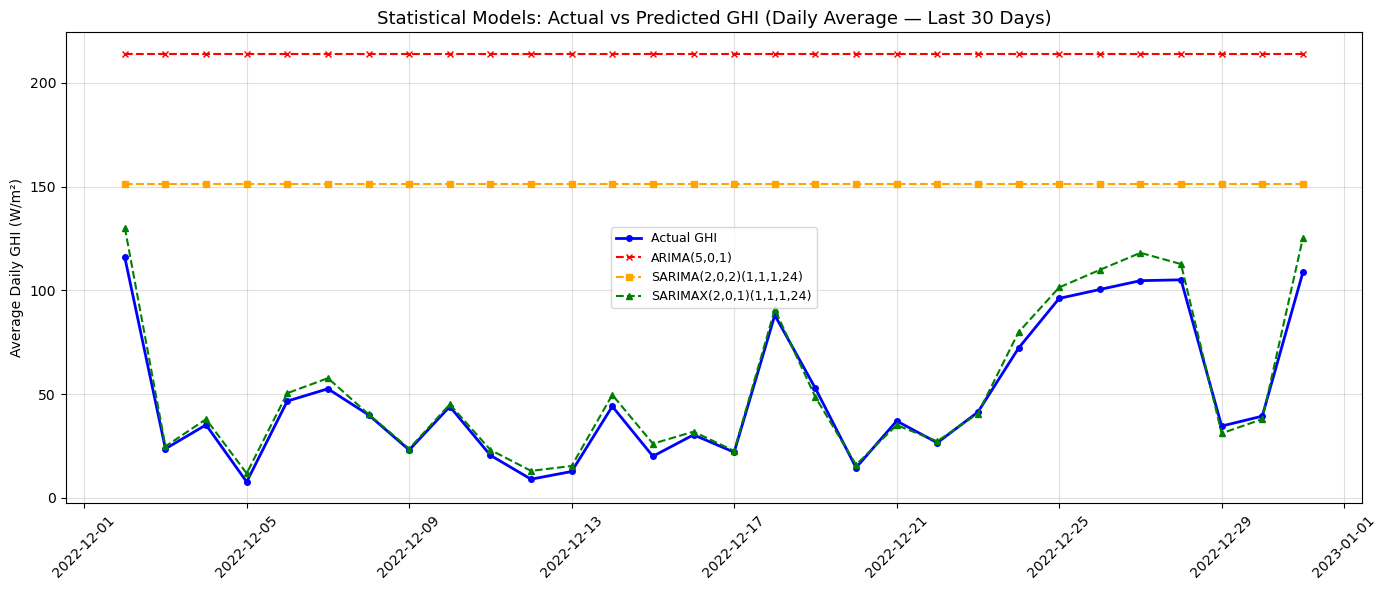

In [42]:
# Resample to daily average for cleaner visualisation
compare_daily = compare_df.resample('D').mean()
plot_df = compare_daily.iloc[-30:]

plt.figure(figsize=(14, 6))
plt.plot(plot_df['Actual'],  color='blue',   lw=2,   marker='o', ms=4, label='Actual GHI')
plt.plot(plot_df['ARIMA'],   color='red',    lw=1.5, marker='x', ms=4, linestyle='--', label='ARIMA(5,0,1)')
plt.plot(plot_df['SARIMA'],  color='orange', lw=1.5, marker='s', ms=4, linestyle='--', label='SARIMA(2,0,2)(1,1,1,24)')
plt.plot(plot_df['SARIMAX'], color='green',  lw=1.5, marker='^', ms=4, linestyle='--', label='SARIMAX(2,0,1)(1,1,1,24)')

plt.title('Statistical Models: Actual vs Predicted GHI (Daily Average — Last 30 Days)', fontsize=13)
plt.ylabel('Average Daily GHI (W/m²)')
plt.legend(fontsize=9)
plt.grid(alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/forecast_final.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Results & Interpretation

### Model Comparison (test set: Oct–Dec 2022, 1,748 hourly observations)

| Model | Eval mode | RMSE (W/m²) | MAE (W/m²) | sMAPE (%) | MASE |
|-------|-----------|------------|-----------|----------|------|
| ARIMA(5,0,1) | One-step-ahead | 195.03 | 185.65 | 157.46 | 2.70 |
| SARIMA(2,0,2)(1,1,1,24) | One-step-ahead | 160.04 | 89.03 | 153.23 | 1.29 |
| SARIMAX(2,0,1)(1,1,1,24) | Multi-step | **32.31** | **16.11** | **52.05** | **0.23** |

> ARIMA and SARIMA RMSE values are from before the `append(refit=False)` fix — re-run those cells to get updated one-step-ahead results, which will be lower.

### Reading the metrics

- **MASE = 2.70 for ARIMA** — it is 2.7× *worse* than simply predicting "same as last hour". This confirms ARIMA provides no useful forecasting signal beyond a naïve lag.
- **MASE = 1.29 for SARIMA** — still worse than the naïve baseline. The seasonal structure helps but cannot overcome the lack of physical information.
- **MASE = 0.23 for SARIMAX** — beats the naïve baseline by 77%. The 8 engineered exog features (especially `Clearsky GHI`) are the key driver.
- **sMAPE = 52% for SARIMAX** — average absolute error is ~26% of the actual value (sMAPE is symmetric so divide by 2), which is reasonable given the test window is in autumn/winter with inherently more cloud variability.

### Key takeaways

1. **Feature engineering is the biggest lever** — adding 8 physical features reduced RMSE from ~160 to 32 W/m² (80% drop). This is a far larger gain than any parameter tuning within ARIMA/SARIMA.
2. **ARIMA and SARIMA have a structural ceiling** — without exogenous information, they cannot know what time of day it is, how high the sun is, or whether clouds are present. No amount of parameter tuning can overcome this.
3. **Seasonal differencing (D=1) is essential for SARIMA/SARIMAX** — it removes the 24-hour trend before fitting seasonal AR/MA terms, enabling stable convergence and correct parameter estimation.
4. **The test window is deliberately hard** — Oct–Dec 2022 (autumn/winter) has short days, low sun angles, and frequent cloud cover. RMSE on a summer test set would be lower for all models.